In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [3]:
df.sample(10)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
1552583,1751251,B099NP2VQP,Vertbaudet Boys Black Contrast Stripe Sweat Pants,0.0,0,16.00,False,0,Sports & Outdoors
1834469,2062497,B09NGCM874,"IOHGbo Stickers for Skateboard, Animal Dragon ...",0.0,0,23.99,False,0,Sports & Outdoors
2399292,2769992,B000K6720K,Energizer Watch Coin Battery 371,4.6,566,2.86,False,0,"Household Batteries, Chargers & Accessories"
2226272,2573297,B097PZVSJJ,"IKEA LATT Children's Table with 2 Chairs, Whit...",4.7,15,42.99,False,200,Baby
377633,403600,B0B6R8J9RC,YUANCHENG Men's Short Sleeve Hawaiian Shirt Ca...,0.0,0,22.49,False,0,Sports & Outdoors
1436621,1579910,B0CDLRFQPK,Roll Out Gymnastics Mat Lightweight Durable Wr...,0.0,0,303.37,False,0,Sports & Outdoors
416512,446958,B0CF4HTRBK,"LUNezy Work Tops for Women, Women's New Button...",0.0,0,12.99,False,0,Sports & Outdoors
1292356,1428856,B07DGNX8T2,"AILUZE Garden Hose 100FT,Expanding Garden Wate...",4.0,4202,19.99,False,0,Gardening
875764,953189,B07TLZD8JJ,Fimpex Compatible Ink Cartridge Replacement fo...,3.8,13,9.99,False,0,Printers & Accessories
1433254,1576353,B073PZ92PJ,MaxStrength Boxing Power Bag Filled Sand Bag 5...,4.2,35,37.85,False,0,Sports & Outdoors


In [4]:
df.shape

(2443651, 9)

In [5]:
df['category'].nunique()

296

In [6]:
#Part 1: Understanding Product Categories

# Frequency Tables:
# According to the following frequency table we can observe that the top 5 most listed products categories are: 
# - Sports & Outdoors
# - Beauty                                     
# - Handmade Clothing, Shoes & Accessories    
# - Bath & Body                              
# - Birthday Gifts                                                                                                                                         

In [7]:
frequency_table = df['category'].value_counts(ascending=False)
frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [8]:
# Visualizations:

# On the following Bar chart we can see the distribution of products across different categories for a subset of top categories.
# On the following Pie chart we can see the proportion for the same subset of top categories. The category 'Sports & Outdoors' is dominating the listing. 

In [9]:
top_categories = df['category'].value_counts().head(5).index
df_top = df[df['category'].isin(top_categories)]

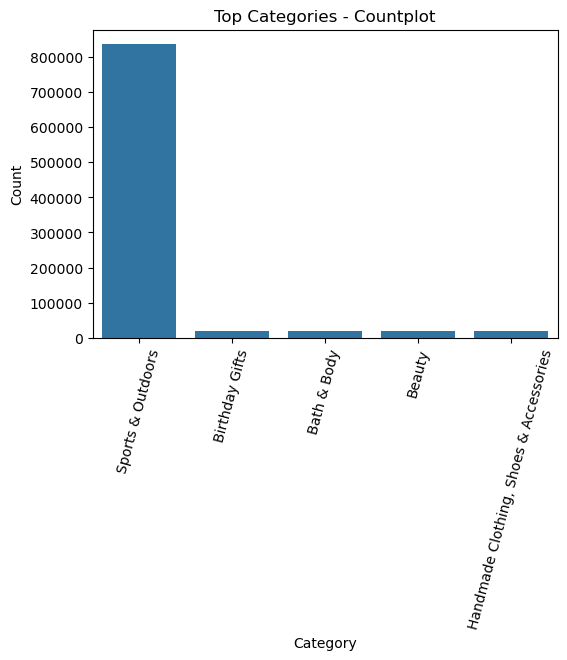

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='category', data=df_top)
plt.title("Top Categories - Countplot")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=75) 
plt.show()

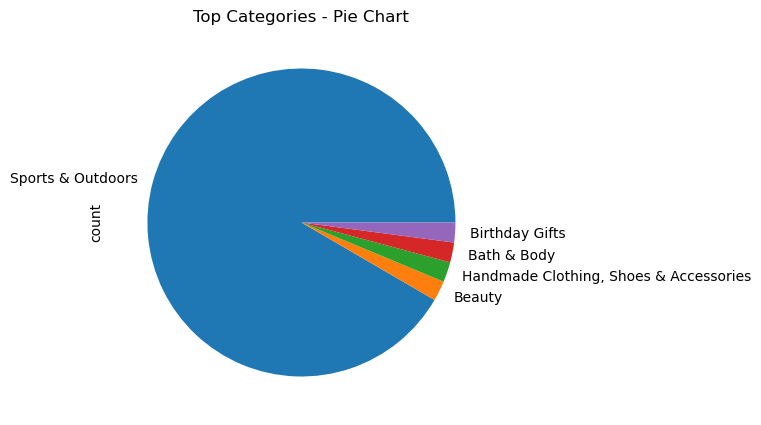

In [11]:
plt.figure(figsize=(5, 5))
df_top['category'].value_counts().plot.pie()
plt.title("Top Categories - Pie Chart")
plt.show()

In [12]:
# Part 2: Delving into Product Pricing

# Measures of Centrality: 
# Mean: 89.24
# Median: 19.09
# Mode: 9.99
# The average price point of products listed is: 89.24  
# We can see that the average price point of products listed (mean) is greater than the most common price point (mode). 
# This means there are some high-priced products pulling the average upward — a right-skewed distribution.

In [13]:
price_mean = df['price'].mean().round(2)
price_median = df['price'].median()
price_mode = df['price'].mode()[0]
print(f"Mean: {price_mean}")
print(f"Median: {price_median}")
print(f"Mode: {price_mode}")

Mean: 89.24
Median: 19.09
Mode: 9.99


In [14]:
# Measures of Dispersion:
# Variance: 119445.49
# Standard deviation: 345.61
# Range es: 100000.0
# The interquartile range for product price (IQR) is: 36.0
#The product prices show a significant overall spread due to extreme outliers or a few very expensive products. Most prices, however, appear to be fairly consistent (as indicated by the small IQR).

In [15]:
p_var = round(df['price'].var(), 2) # Varianza 
p_std = round(df['price'].std(), 2) # Desviación Standart 
print(f"Variance: {p_var}")
print(f"Standard deviation: {p_std}")

Variance: 119445.49
Standard deviation: 345.61


In [16]:
p_max = df['price'].max() # Máximo
p_min = df['price'].min() # Mínimo
p_range = p_max - p_min #Range
print(f"Valor máximo es: {p_max}")
print(f"Valor mínimo es: {p_min}")
print(f"Range es: {p_range}")

Valor máximo es: 100000.0
Valor mínimo es: 0.0
Range es: 100000.0


In [17]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
print("The interquartile range for product price (IQR) is:", IQR)

The interquartile range for product price (IQR) is: 36.0


In [18]:
#Visualizations:

#We plot a histogram to visualize the distribution of the product prices, but it's difficult to read as there are outliers. We can solve this problem removing outliers beyond the 95th percentile
# We can also observe than most of the product fall on a range between 0 and 25 aproximetly.

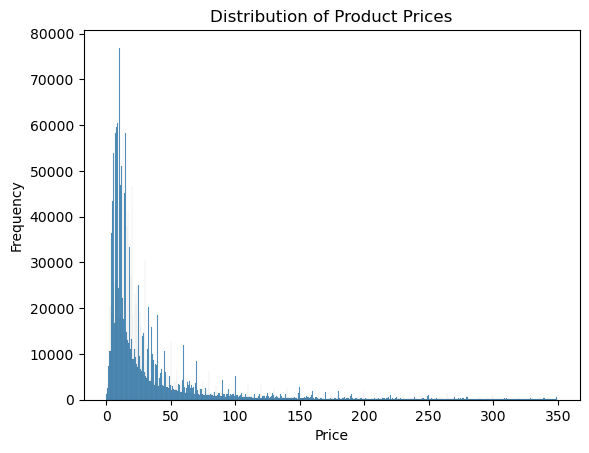

In [19]:
q95 = df['price'].quantile(0.95)
filtered_df = df[df['price'] <= q95]
sns.histplot(data=filtered_df, x='price') 
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Product Prices')
plt.show()

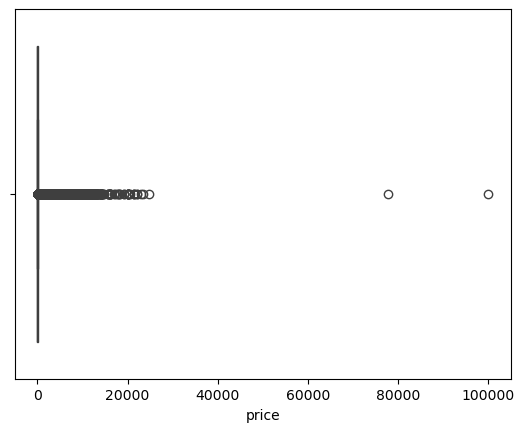

In [20]:
# With this Boxplot we can see clearly the outliers
sns.boxplot(x=df['price'])
plt.show()

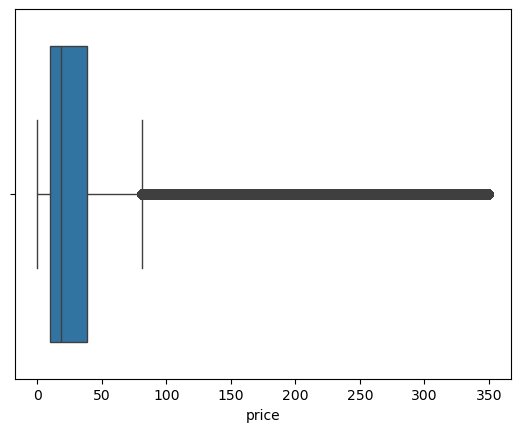

In [21]:
#Using the filtered data frame where we removed outliers beyond the 95th percentile we an see more clearly the information on the graph. 
sns.boxplot(x=filtered_df['price'])
plt.show()

In [22]:
#Part 3: Unpacking Product Ratings

# To be able to analyse the way customers rate products in Amazon Uk first we need to remove the 0.00 rating that corresponde to 0 reviews and not to negative reviews. 

df_filtered = df[df['reviews'] > 0]

In [23]:
# Measures of Centrality:
# This information show us that the mean media and mode are all above 4 wich suggests the customers are satisfied and give high ratings to the products. 
# The mode = 4.5 is the most frequently given rating.

reviews_mean = df_filtered['stars'].mean().round(2)
reviews_median = df_filtered['stars'].median()
reviews_mode = df_filtered['stars'].mode()[0]
print(f"Mean: {reviews_mean}")
print(f"Median: {reviews_median}")
print(f"Mode: {reviews_mode}")

Mean: 4.32
Median: 4.4
Mode: 4.5


In [24]:
# Variance, Standard Deviation, and Interquartile Range (IQR)
# Ratings are fairly consistent, clustering around 4 – 4.5 stars, with a few low ratings creating the left tail.
# the standar deviation and variance show a relatively low spread.

reviews_variance = round(df_filtered['stars'].var(), 2)
reviews_std_dev = round(df_filtered['stars'].std(), 2)
reviews_iqr = df_filtered['stars'].quantile(0.75) - df_filtered['stars'].quantile(0.25)

print(f"Variance: {reviews_variance}")
print(f"Standard Deviation: {reviews_std_dev}")
print(f"Interquartile Range (IQR): {reviews_iqr}")

Variance: 0.31
Standard Deviation: 0.56
Interquartile Range (IQR): 0.5


In [25]:
# Skewness and Kurtosis
# Ratings are not normally distributed. They lean heavily towards higher ratings, with occasional low ratings that create a left tail.

skewness = df_filtered['stars'].skew()
kurtosis = df_filtered['stars'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: -2.3795681122127945
Kurtosis: 9.78193769066435


In [ ]:
# The most common rating is 4.5
sns.histplot(data=df_filtered, x="stars", bins=20, kde=True)
plt.show()